# 04: Walk-Forward ML Ranking

**Thin client** over `src/models`. Runs the expanding-window walk-forward for the
baseline (ElasticNet) and tree (LightGBM) models, compares out-of-sample IC, and
runs the **leakage test** (shuffled target → IC ≈ 0). Then exercises the two
production capabilities behind `pipelines/train.py` + `pipelines/predict.py`:
**nested-CV hyperparameter tuning** and the **deployment model artifact** used for
inference without re-training.

**Data source:** the gold `panel_monthly` table in the warehouse
(`warehouse.load_panel_monthly()`) — the full investable universe, the same
matrix the `train.py` pipeline trains on. Requires `POSTGRES_PASSWORD` (and
`FACTOR_DB_HOST` if off-LAN).

In [1]:
import sys; sys.path.insert(0, '..')
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import db, warehouse
from src.factors import evaluate
from src.factors.panel import _feature_list
from src.models import rankers, walkforward

plt.style.use('seaborn-v0_8-whitegrid')

# Read the gold training matrix from the warehouse (production source of truth).
assert db.ping(), "DB unreachable — set POSTGRES_PASSWORD (and FACTOR_DB_HOST if off-LAN)"
panel = warehouse.load_panel_monthly()
features = _feature_list()
print('panel:', panel.shape, '| features:', len(features),
      '|', panel.ticker.nunique(), 'tickers')

panel: (1280046, 22) | features: 16 | 4038 tickers


In [2]:
# Walk-forward OOS predictions for each model
results = {}
for name in ['elasticnet', 'lightgbm']:
    preds = walkforward.walk_forward_predict(panel, rankers.get_model_factory(name), features)
    ic = evaluate.information_coefficient(preds, 'pred', target='forward_return')
    results[name] = (preds, ic, evaluate.ic_summary(ic))

summary = pd.DataFrame({k: v[2] for k, v in results.items()}).T
summary.round(4)

,ic_mean,ic_std,ic_ir,t_stat,hit_rate,n_months
elasticnet,0.0236,0.1171,0.2014,3.3635,0.6022,279.0
lightgbm,0.0310,0.0712,0.4350,7.2668,0.7133,279.0


## Leakage test — shuffled target must give IC ≈ 0

In [3]:
np.random.seed(42)
shuffled = panel.copy()
shuffled['target'] = shuffled.groupby('date')['target'].transform(lambda s: s.sample(frac=1).values)
preds_sh = walkforward.walk_forward_predict(shuffled, rankers.get_model_factory('elasticnet'), features)
ic_sh = evaluate.information_coefficient(preds_sh, 'pred', target='forward_return')
sh = evaluate.ic_summary(ic_sh)
real = results['elasticnet'][2]

print(f"Real:     mean IC {real['ic_mean']:+.4f}, t-stat {real['t_stat']:+.2f}, n {real['n_months']:.0f}")
if sh['n_months'] == 0:
    print("Shuffled: no scoreable months — ElasticNet regularizes a noise target to "
          "constant within-date predictions, i.e. zero extractable signal.")
else:
    print(f"Shuffled: mean IC {sh['ic_mean']:+.4f}, t-stat {sh['t_stat']:+.2f}, n {sh['n_months']:.0f}")

# Leakage gate: a shuffled (noise) target must not yield significant predictive
# power. On the full universe ElasticNet's L1 zeros every coefficient, so the
# shuffled model predicts a constant per date (no cross-sectional signal at all) —
# the strongest possible pass (no scoreable months). Otherwise the shuffled
# t-stat must be insignificant. (NaN-safe: abs(nan) < 2 is False.)
assert sh['n_months'] == 0 or abs(sh['t_stat']) < 2.0, 'Leakage! shuffled signal is significant'
print('\nLeakage test PASSED: shuffled target yields no significant IC.')

Real:     mean IC +0.0236, t-stat +3.36, n 279
Shuffled: no scoreable months — ElasticNet regularizes a noise target to constant within-date predictions, i.e. zero extractable signal.

Leakage test PASSED: shuffled target yields no significant IC.


## Cumulative IC over time

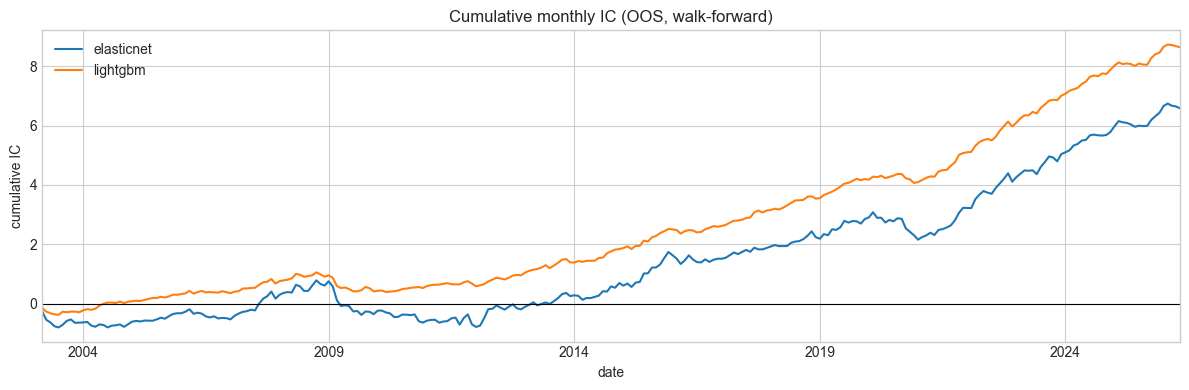

In [4]:
fig, ax = plt.subplots(figsize=(12, 4))
for name, (_, ic, _) in results.items():
    ic.sort_index().cumsum().plot(ax=ax, label=name)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Cumulative monthly IC (OOS, walk-forward)')
ax.set_ylabel('cumulative IC'); ax.legend()
plt.tight_layout(); plt.show()

## Hyperparameter tuning (nested walk-forward)

Each fold's hyperparameters are chosen by **inner** time-ordered CV on its own
training window — causal, since the outer test block is never seen — and re-tuned
every `config['tuning']['retune_every']` folds. Params in `config/model.yaml`
given as lists are the search grid; the first element is the default.

Demonstrated here on **ElasticNet** (fast). LightGBM tuning uses the *identical*
code path but is far heavier (hundreds of GBM fits across the re-tune points) — run
it via `python -m pipelines.train --model lightgbm`. Tuning need not beat the
fixed config: on noisy financial data the gain is often small — this is the honest
comparison.

In [5]:
from src.config import load_config
mcfg = load_config('model')

# Nested-CV tuning on ElasticNet (fast). Each fold's params are chosen by inner-CV
# on its training window, re-tuned periodically. (LightGBM: same call with
# model_name='lightgbm' — run via pipelines/train.py, it's much slower.)
preds_tuned = walkforward.walk_forward_predict(
    panel, features=features, model_name='elasticnet', tune=True, cfg=mcfg)
tuned_sum = evaluate.ic_summary(
    evaluate.information_coefficient(preds_tuned, 'pred', target='forward_return'))

pd.DataFrame({'elasticnet_fixed': results['elasticnet'][2],
              'elasticnet_tuned': tuned_sum}).T.round(4)

,ic_mean,ic_std,ic_ir,t_stat,hit_rate,n_months
elasticnet_fixed,0.0236,0.1171,0.2014,3.3635,0.6022,279.0
elasticnet_tuned,0.0196,0.1160,0.1691,2.7883,0.6066,272.0


In [6]:
# Hyperparameters chosen at each re-tune point (inner-CV winners over time)
hist = pd.json_normalize(preds_tuned.attrs['tuning_history'])
print(f"Re-tuned {len(hist)}x across the walk-forward "
      f"(every {mcfg['tuning']['retune_every']} folds).")
hist

Re-tuned 24x across the walk-forward (every 12 folds).


,date,inner_ic,params.enabled,params.alpha,params.l1_ratio
0,2003-03-31,0.137537,True,0.0010,0.5
1,2004-03-31,-0.033392,True,0.0010,0.8
2,2005-03-31,0.038850,True,0.0001,0.2
3,2006-03-31,0.034296,True,0.0010,0.2
4,2007-03-31,0.000692,True,0.0001,0.2
5,2008-03-31,0.023322,True,0.0001,0.2
6,2009-03-31,-0.005819,True,0.0001,0.2
7,2010-03-31,0.014257,True,0.0010,0.8
8,2011-03-31,-0.071045,True,0.0010,0.5
9,2012-03-31,-0.067643,True,0.0001,0.2


## Deployment artifact + inference (no retrain)

After validation, fit **one** model on all data and persist it
(`models/<horizon>/<version>/` = `model.joblib` + `manifest.json`). Inference
loads that artifact and scores the latest cross-section — never re-training. The
imputer is bundled in the model pipeline, so preprocessing is identical to
training; `predict_with_artifact` additionally asserts the live feature set
matches the manifest (the train/serve **skew guard**). *Mirrors
`pipelines/train.py` → `pipelines/predict.py`; here we fit LightGBM once with the
config-default params for a quick single-fit demo (train.py tunes it first).*

In [7]:
from datetime import datetime, timezone
from src.models import artifact

# Fit ONE LightGBM deployment model on all data, then persist it. Mirrors
# pipelines/train.py (which additionally tunes the deployment params; here we use
# the config defaults for a quick, single-fit demo).
fit_df = panel.dropna(subset=['target'])
dep_params = rankers.default_params(mcfg['models']['lightgbm'])
model = rankers.build_model('lightgbm', dep_params)
model.fit(fit_df[features], fit_df['target'])     # pipeline imputes internally

man = artifact.Manifest(
    model_version=artifact.make_version('lightgbm', '1m'),
    model_name='lightgbm', horizon='1m', feature_list=features,
    hyperparams=dep_params,
    normalization=load_config('features')['normalization']['scheme'], target='target',
    train_start=str(fit_df.date.min().date()), train_end=str(fit_df.date.max().date()),
    n_train_rows=int(len(fit_df)),
    oos_metrics={k: float(results['lightgbm'][2][k])
                 for k in ('ic_mean', 'ic_ir', 't_stat', 'hit_rate')},
    code_sha=artifact._git_sha(),
    created_at=datetime.now(timezone.utc).isoformat(timespec='seconds'))
print('saved artifact ->', artifact.save_artifact(model, man))

# Inference: load the artifact and score the latest cross-section — NO re-training.
loaded, manifest = artifact.load_artifact('1m')
asof = panel.date.max()
cross = panel[panel.date == asof].copy()
cross['pred'] = artifact.predict_with_artifact(cross, '1m')

# Train/serve skew guard: a missing feature is caught, not silently mis-scored.
try:
    artifact.predict_with_artifact(cross.drop(columns=['roe']), '1m')
except ValueError as e:
    print('skew guard caught:', str(e)[:72], '...')

print(f"\nTop 15 as-of {asof.date()} (model {manifest.model_version}):")
cross.sort_values('pred', ascending=False)[['ticker', 'gics_sector', 'pred']].head(15)

saved artifact -> models/1m/lightgbm-1m-20260603185111
skew guard caught: live features missing manifest columns (train/serve skew): ['roe'] ...

Top 15 as-of 2026-06-30 (model lightgbm-1m-20260603185111):


,ticker,gics_sector,pred
1279069,REI,Energy,0.559237
1279100,RILY,Financials,0.556177
1276825,CLNE,Utilities,0.551776
1277056,DDI,Information Technology,0.548452
1279593,TLRY,Health Care,0.547120
1279336,SLQT,Financials,0.546018
1276753,CENX,Materials,0.545643
1279090,RGP,Industrials,0.544832
1277885,INM,Health Care,0.544163
1279586,TK,Industrials,0.543596


## Notes

- Over the full universe, LightGBM beats the single-signal (notebook 03) and
  ElasticNet baselines by capturing factor interactions.
- The leakage test (shuffled target) is the key integrity gate: OOS IC must be
  statistically insignificant.
- **Tuning** is causal (inner-CV inside each train window) and may or may not beat
  the fixed config — judge it on OOS IC, not inner-CV scores.
- The **artifact** (`model.joblib` + `manifest.json`) is what inference loads; the
  bundled imputer + the manifest feature-list check keep train and serve identical.
  `pipelines/train.py` produces it for real; this notebook only illustrates it.
- **Next**: `notebooks/05_backtest_report.ipynb` — long-only portfolio + cost-aware backtest.